## AGN Homework 4 – Photometric Reverberation Mapping

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

import photRM

from pyzdcf import pyzdcf

%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [2]:
print(photRM.__doc__)


Module name: photRM

Authors: Isidora Jankov & Dr. Andjelka Kovačević

Contact: ijankov@proton.me
------------------------------------------------

Description:
------------
A set of functions for:

- generating artificial AGN light curves using a method based on the Damped 
  Random Walk process where real physical AGN quantities are taken into account 
  (see Kovačević et al. 2021).
- generating artificial AGN photometric light curves for testing photometric 
  reverberation mapping methods (see Jankov et al. 2022).
- implementation of photometric reverberation mapping formalism described in 
  Chelouche & Daniel (2012)
- utility functions for preparing these light curves for pyZDCF 
  (Jankov et al., in prep), ZDCF and PLIKE programs (Alexander 1997).
  
Python functions for generating artificial light curves (lc_conti, lc_response,
lc_merged), as well as filters_viz() are adapted from original python code 
written by Dr. Andjelka Kovačević. There were several improvements introduc

## 1. Synthetic Lightcurves

### a)

In [3]:
print(photRM.lc_two_bands.__doc__)


    Generate two artificial light curves: 
        
        - one in the hypothetical X band covering solely the continuum emission;
        - one in the hypothetical Y band covering some emission line and its
          surrounding continuum;
    
    The X band light curve is generated using a stochastic model based on the 
    Damped random walk (DRW) proccess (see lc_conti() docs). The Y band light
    curve is modeled using a method described in Jankov et al. (2022) which is 
    based on the photoRM formalism by Chelouche & Daniel (2012).

    Parameters
    ----------
    T: int
        Total time span of the light curve. It is recommended to generate light
        curves to be at least 10 times longer than their characteristic 
        timescale (Kozłowski 2017). 
    osc: bool, default=True
        If True, light curve simulation will take an oscillatory signal into 
        account.
    A: float, default=0.14
        Amplitude of the oscillatory signal in magnitudes (used onl

#### Task:

- generate three pairs of continuum and emission line lightcurves
- plot and compare resulting parameters and simulation data

#### Result:

Properties of the simulated AGN object:
---------------------------------------
log(L) = 43.00
MBH = 3.14e+06 M_sun
tau_DRW = 17.31 days
sigma_DRW = 0.05 mag^2/day
Time-lag = 9.86 days

Properties of the simulated AGN object:
---------------------------------------
log(L) = 44.00
MBH = 1.46e+07 M_sun
tau_DRW = 31.98 days
sigma_DRW = 0.03 mag^2/day
Time-lag = 33.65 days

Properties of the simulated AGN object:
---------------------------------------
log(L) = 45.00
MBH = 6.76e+07 M_sun
tau_DRW = 59.10 days
sigma_DRW = 0.01 mag^2/day
Time-lag = 114.82 days



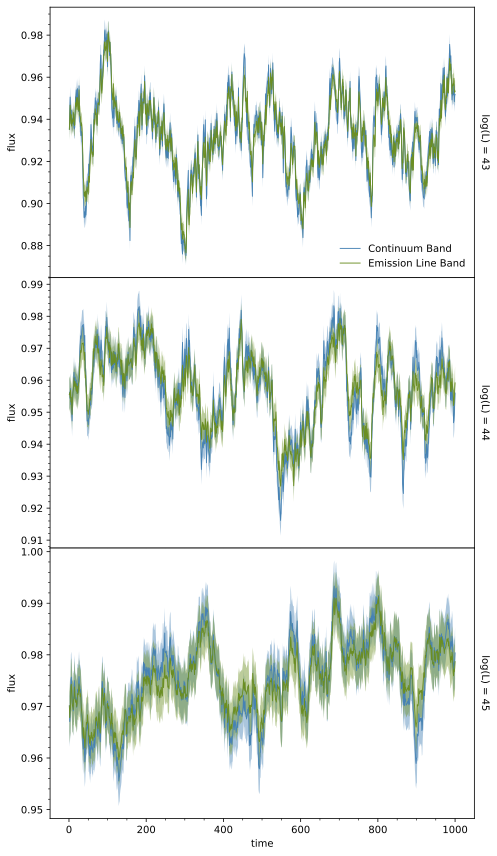

In [4]:
x_band_43, y_band_43, line_response_43 = photRM.lc_two_bands(T = 5000, z = 0.1, lum = 43, wl = 0.25, wc = 0.75)
print()
x_band_44, y_band_44, line_response_44 = photRM.lc_two_bands(T = 5000, z = 0.1, lum = 44, wl = 0.25, wc = 0.75)
print()
x_band_45, y_band_45, line_response_45 = photRM.lc_two_bands(T = 5000, z = 0.1, lum = 45, wl = 0.25, wc = 0.75)
print()

fig, axs = plt.subplots(3, 1, figsize=[7, 12], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].fill_between(x_band_43['t'][:1000],
                    x_band_43['flux'][:1000] - x_band_43['err'][:1000],
                    x_band_43['flux'][:1000] + x_band_43['err'][:1000],
                    fc='steelblue', ec='none', alpha=0.45)
axs[0].plot(x_band_43['t'][:1000], x_band_43['flux'][:1000], c='steelblue', lw=0.9, label='Continuum Band')
axs[0].fill_between(y_band_43['t'][:1000],
                    y_band_43['flux'][:1000] - y_band_43['err'][:1000],
                    y_band_43['flux'][:1000] + y_band_43['err'][:1000],
                    fc='olivedrab', ec='none', alpha=0.45)
axs[0].plot(y_band_43['t'][:1000], y_band_43['flux'][:1000], c='olivedrab', lw=0.9, label='Emission Line Band')
axs[0].annotate('log(L) = 43', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('flux')
axs[0].legend()

axs[1].fill_between(x_band_44['t'][:1000],
                    x_band_44['flux'][:1000] - x_band_44['err'][:1000],
                    x_band_44['flux'][:1000] + x_band_44['err'][:1000],
                    fc='steelblue', ec='none', alpha=0.45)
axs[1].plot(x_band_44['t'][:1000], x_band_44['flux'][:1000], c='steelblue', lw=0.9)
axs[1].fill_between(y_band_44['t'][:1000],
                    y_band_44['flux'][:1000] - y_band_44['err'][:1000],
                    y_band_44['flux'][:1000] + y_band_44['err'][:1000],
                    fc='olivedrab', ec='none', alpha=0.45)
axs[1].plot(y_band_44['t'][:1000], y_band_44['flux'][:1000], c='olivedrab', lw=0.9)
axs[1].annotate('log(L) = 44', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[1].set_ylabel('flux')

axs[2].fill_between(x_band_45['t'][:1000],
                    x_band_45['flux'][:1000] - x_band_45['err'][:1000],
                    x_band_45['flux'][:1000] + x_band_45['err'][:1000],
                    fc='steelblue', ec='none', alpha=0.45)
axs[2].plot(x_band_45['t'][:1000], x_band_45['flux'][:1000], c='steelblue', lw=0.9)
axs[2].fill_between(y_band_45['t'][:1000],
                    y_band_45['flux'][:1000] - y_band_45['err'][:1000],
                    y_band_45['flux'][:1000] + y_band_45['err'][:1000],
                    fc='olivedrab', ec='none', alpha=0.45)
axs[2].plot(y_band_45['t'][:1000], y_band_45['flux'][:1000], c='olivedrab', lw=0.9)
axs[2].annotate('log(L) = 45', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[2].set_ylabel('flux')
axs[2].set_xlabel('time')

plt.show()
plt.close()

with open('data/x_band_43.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(x_band_43['t'][:1000], x_band_43['flux'][:1000], x_band_43['err'][:1000]):
        f.write(templ.format(*line))
with open('data/y_band_43.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(y_band_43['t'][:1000], y_band_43['flux'][:1000], y_band_43['err'][:1000]):
        f.write(templ.format(*line))
with open('data/line_response_43.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(line_response_43['t'][:1000], line_response_43['flux'][:1000], line_response_43['err'][:1000]):
        f.write(templ.format(*line))

with open('data/x_band_44.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(x_band_44['t'][:1000], x_band_44['flux'][:1000], x_band_44['err'][:1000]):
        f.write(templ.format(*line))
with open('data/y_band_44.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(y_band_44['t'][:1000], y_band_44['flux'][:1000], y_band_44['err'][:1000]):
        f.write(templ.format(*line))
with open('data/line_response_44.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(line_response_44['t'][:1000], line_response_44['flux'][:1000], line_response_44['err'][:1000]):
        f.write(templ.format(*line))

with open('data/x_band_45.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(x_band_45['t'][:1000], x_band_45['flux'][:1000], x_band_45['err'][:1000]):
        f.write(templ.format(*line))
with open('data/y_band_45.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(y_band_45['t'][:1000], y_band_45['flux'][:1000], y_band_45['err'][:1000]):
        f.write(templ.format(*line))
with open('data/line_response_45.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(line_response_45['t'][:1000], line_response_45['flux'][:1000], line_response_45['err'][:1000]):
        f.write(templ.format(*line))

#### Explanation:

- larger time lags for higher luminosity
- broad line region pushed further from central engine by intense radiation

### b)

#### Task:

- estimate time lag
- plot results

#### Result:

In [5]:
par_dict = {
    'autocf': True,
    'prefix': 'acf_43',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_43.txt'
}

acf_43 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_43',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_43.txt',
    'lc2_name': 'y_band_43.txt',
}

ccf_43 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': True,
    'prefix': 'acf_44',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44.txt'
}

acf_44 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_44',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44.txt',
    'lc2_name': 'y_band_44.txt',
}

ccf_44 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': True,
    'prefix': 'acf_45',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_45.txt'
}

acf_45 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_45',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_45.txt',
    'lc2_name': 'y_band_45.txt',
}

ccf_45 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

990 bins actually used, 45.0 inter-dependent pairs discarded.


acf_43.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   False
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

992 bins actually used, 500032 inter-dependent pairs discarded.


ccf_43.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

990 bins actually used, 45.0 inter-dependent p

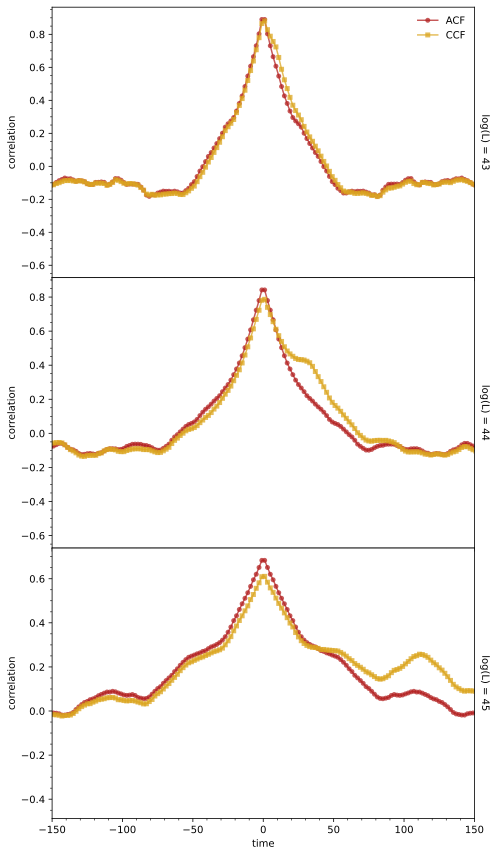

In [6]:
acf_43 = photRM.add_inverted_acf(acf_43)
acf_44 = photRM.add_inverted_acf(acf_44)
acf_45 = photRM.add_inverted_acf(acf_45)

acf_43 = acf_43.drop_duplicates(subset=['tau']).sort_values('tau')
acf_44 = acf_44.drop_duplicates(subset=['tau']).sort_values('tau')
acf_45 = acf_45.drop_duplicates(subset=['tau']).sort_values('tau')

acf_43 = photRM.interp(ccf_43, acf_43)
acf_44 = photRM.interp(ccf_44, acf_44)
acf_45 = photRM.interp(ccf_45, acf_45)

fig, axs = plt.subplots(3, 1, figsize=[7, 12], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_43['tau'], acf_43['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_43['tau'], ccf_43['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('log(L) = 43', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-150, 150)
axs[0].legend()

axs[1].plot(acf_44['tau'], acf_44['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75)
axs[1].plot(ccf_44['tau'], ccf_44['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75)
axs[1].annotate('log(L) = 44', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[1].set_ylabel('correlation')
axs[1].set_xlim(-150, 150)

axs[2].plot(acf_45['tau'], acf_45['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75)
axs[2].plot(ccf_45['tau'], ccf_45['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75)
axs[2].annotate('log(L) = 45', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[2].set_ylabel('correlation')
axs[2].set_xlabel('time')
axs[2].set_xlim(-150, 150)

plt.show()
plt.close()

In [7]:
print(photRM.peak_finder.__doc__)


    Find highest positive peak in a user defined interval. Useful for finding
    coresponding time-lag in CCF. By setting first=True, you can also specify 
    that you want to select first peak found in a given interval, instead of 
    the highest one.
    


Peak candidates (x-axis vals):  [ 9. 35. 47.]
Max. peak:  9.0
Peak candidates (x-axis vals):  [33.]
Max. peak:  33.0
Peak candidates (x-axis vals):  [115.]
Max. peak:  115.0


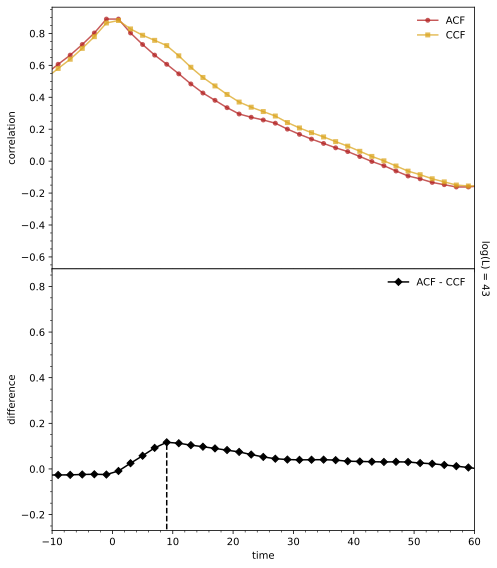

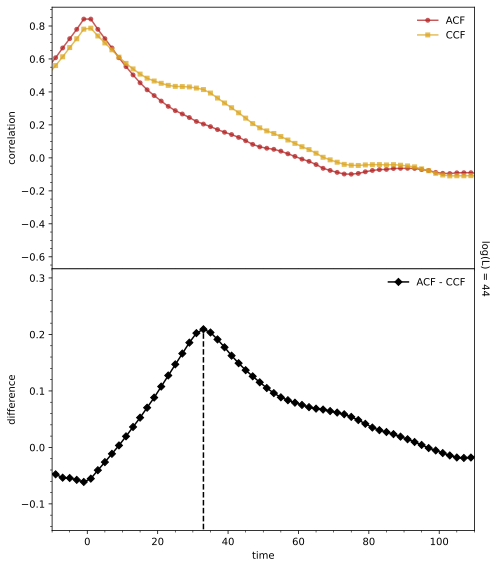

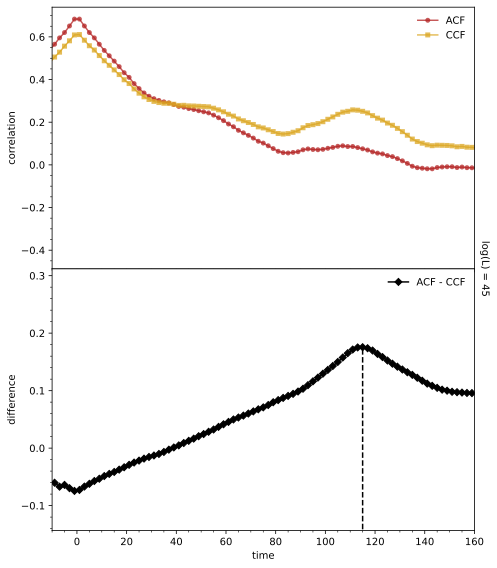

In [8]:
diff_43 = photRM.delta_ccf(acf_43, ccf_43)
diff_44 = photRM.delta_ccf(acf_44, ccf_44)
diff_45 = photRM.delta_ccf(acf_45, ccf_45)

tau_43, peaks_x_43, peaks_y_43 = photRM.peak_finder(diff_43.dcf.values, diff_43.tau.values, (0,50))
tau_44, peaks_x_44, peaks_y_44 = photRM.peak_finder(diff_44.dcf.values, diff_44.tau.values, (0,100))
tau_45, peaks_x_45, peaks_y_45 = photRM.peak_finder(diff_45.dcf.values, diff_45.tau.values, (0,150))

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_43['tau'], acf_43['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_43['tau'], ccf_43['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('log(L) = 43', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-10, 60)
axs[0].legend()

axs[1].plot(diff_43['tau'], diff_43['dcf'], 'D-k', ms=5, label='ACF - CCF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_43[0], -100, peaks_y_43[0], ls='--', color='k')
axs[1].set_xlim(-10, 60)
axs[1].legend()

plt.show()
plt.close()

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_44['tau'], acf_44['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_44['tau'], ccf_44['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('log(L) = 44', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-10, 110)
axs[0].legend()

axs[1].plot(diff_44['tau'], diff_44['dcf'], 'D-k', ms=5, label='ACF - CCF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_44[0], -100, peaks_y_44[0], ls='--', color='k')
axs[1].set_xlim(-10, 110)
axs[1].legend()

plt.show()
plt.close

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_45['tau'], acf_45['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_45['tau'], ccf_45['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('log(L) = 45', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-10, 160)
axs[0].legend()

axs[1].plot(diff_45['tau'], diff_45['dcf'], 'D-k', ms=5, label='ACF - CCF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_45[0], -100, peaks_y_45[0], ls='--', color='k')
axs[1].set_xlim(-10, 160)
axs[1].legend()

plt.show()
plt.close()

#### Comparison:

- actual and recovered values are comparable

### c)

#### Task:

- investigate gap impact

#### Result:

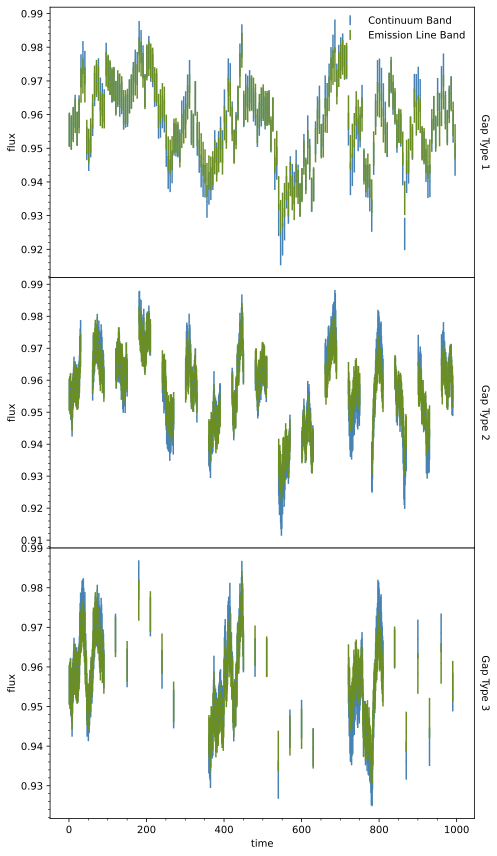

In [9]:
mask_1 = ([True] + [False] * 4) * 200
mask_2 = (([True] * 30 + [False] * 30) * 20)[:1000]
mask_3 = (([True] * 90 + ([False] * 29 + [True]) * 6 + [False] * 90) * 3)[:1000]

x_band_44_gap_1 = {}
x_band_44_gap_1['t'] = np.array(x_band_44['t'][:1000])[mask_1]
x_band_44_gap_1['flux'] = np.array(x_band_44['flux'][:1000])[mask_1]
x_band_44_gap_1['err'] = np.array(x_band_44['err'][:1000])[mask_1]

y_band_44_gap_1 = {}
y_band_44_gap_1['t'] = np.array(y_band_44['t'][:1000])[mask_1]
y_band_44_gap_1['flux'] = np.array(y_band_44['flux'][:1000])[mask_1]
y_band_44_gap_1['err'] = np.array(y_band_44['err'][:1000])[mask_1]

line_response_44_gap_1 = {}
line_response_44_gap_1['t'] = np.array(line_response_44['t'][:1000])[mask_1]
line_response_44_gap_1['flux'] = np.array(line_response_44['flux'][:1000])[mask_1]
line_response_44_gap_1['err'] = np.array(line_response_44['err'][:1000])[mask_1]

x_band_44_gap_2 = {}
x_band_44_gap_2['t'] = np.array(x_band_44['t'][:1000])[mask_2]
x_band_44_gap_2['flux'] = np.array(x_band_44['flux'][:1000])[mask_2]
x_band_44_gap_2['err'] = np.array(x_band_44['err'][:1000])[mask_2]

y_band_44_gap_2 = {}
y_band_44_gap_2['t'] = np.array(y_band_44['t'][:1000])[mask_2]
y_band_44_gap_2['flux'] = np.array(y_band_44['flux'][:1000])[mask_2]
y_band_44_gap_2['err'] = np.array(y_band_44['err'][:1000])[mask_2]

line_response_44_gap_2 = {}
line_response_44_gap_2['t'] = np.array(line_response_44['t'][:1000])[mask_2]
line_response_44_gap_2['flux'] = np.array(line_response_44['flux'][:1000])[mask_2]
line_response_44_gap_2['err'] = np.array(line_response_44['err'][:1000])[mask_2]

x_band_44_gap_3 = {}
x_band_44_gap_3['t'] = np.array(x_band_44['t'][:1000])[mask_3]
x_band_44_gap_3['flux'] = np.array(x_band_44['flux'][:1000])[mask_3]
x_band_44_gap_3['err'] = np.array(x_band_44['err'][:1000])[mask_3]

y_band_44_gap_3 = {}
y_band_44_gap_3['t'] = np.array(y_band_44['t'][:1000])[mask_3]
y_band_44_gap_3['flux'] = np.array(y_band_44['flux'][:1000])[mask_3]
y_band_44_gap_3['err'] = np.array(y_band_44['err'][:1000])[mask_3]

line_response_44_gap_3 = {}
line_response_44_gap_3['t'] = np.array(line_response_44['t'][:1000])[mask_3]
line_response_44_gap_3['flux'] = np.array(line_response_44['flux'][:1000])[mask_3]
line_response_44_gap_3['err'] = np.array(line_response_44['err'][:1000])[mask_3]

fig, axs = plt.subplots(3, 1, figsize=[7, 12], sharex=True, layout='tight', gridspec_kw={'hspace': 0})


axs[0].errorbar(x_band_44_gap_1['t'], x_band_44_gap_1['flux'], yerr=x_band_44_gap_1['err'],
                fmt=',', c='steelblue', label='Continuum Band')
axs[0].errorbar(y_band_44_gap_1['t'], y_band_44_gap_1['flux'], yerr=y_band_44_gap_1['err'],
                fmt=',', c='olivedrab', label='Emission Line Band')
axs[0].annotate('Gap Type 1', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('flux')
axs[0].legend()

axs[1].errorbar(x_band_44_gap_2['t'], x_band_44_gap_2['flux'], yerr=x_band_44_gap_2['err'],
                fmt=',', c='steelblue', label='Continuum Band')
axs[1].errorbar(y_band_44_gap_2['t'], y_band_44_gap_2['flux'], yerr=y_band_44_gap_2['err'],
                fmt=',', c='olivedrab', label='Emission Line Band')
axs[1].annotate('Gap Type 2', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[1].set_ylabel('flux')

axs[2].errorbar(x_band_44_gap_3['t'], x_band_44_gap_3['flux'], yerr=x_band_44_gap_3['err'],
                fmt=',', c='steelblue', label='Continuum Band')
axs[2].errorbar(y_band_44_gap_3['t'], y_band_44_gap_3['flux'], yerr=y_band_44_gap_3['err'],
                fmt=',', c='olivedrab', label='Emission Line Band')
axs[2].annotate('Gap Type 3', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[2].set_ylabel('flux')
axs[2].set_xlabel('time')

plt.show()
plt.close()

with open('data/x_band_44_gap_1.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(x_band_44_gap_1['t'], x_band_44_gap_1['flux'], x_band_44_gap_1['err']):
        f.write(templ.format(*line))
with open('data/y_band_44_gap_1.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(y_band_44_gap_1['t'], y_band_44_gap_1['flux'], y_band_44_gap_1['err']):
        f.write(templ.format(*line))
with open('data/line_response_44_gap_1.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(line_response_44_gap_1['t'], line_response_44_gap_1['flux'], line_response_44_gap_1['err']):
        f.write(templ.format(*line))

with open('data/x_band_44_gap_2.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(x_band_44_gap_2['t'], x_band_44_gap_2['flux'], x_band_44_gap_2['err']):
        f.write(templ.format(*line))
with open('data/y_band_44_gap_2.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(y_band_44_gap_2['t'], y_band_44_gap_2['flux'], y_band_44_gap_2['err']):
        f.write(templ.format(*line))
with open('data/line_response_44_gap_2.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(line_response_44_gap_2['t'], line_response_44_gap_2['flux'], line_response_44_gap_2['err']):
        f.write(templ.format(*line))

with open('data/x_band_44_gap_3.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(x_band_44_gap_3['t'], x_band_44_gap_3['flux'], x_band_44_gap_3['err']):
        f.write(templ.format(*line))
with open('data/y_band_44_gap_3.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(y_band_44_gap_3['t'], y_band_44_gap_3['flux'], y_band_44_gap_3['err']):
        f.write(templ.format(*line))
with open('data/line_response_44_gap_3.txt', 'w') as f:
    templ = '{0} {1} {2}\n'
    for line in zip(line_response_44_gap_3['t'], line_response_44_gap_3['flux'], line_response_44_gap_3['err']):
        f.write(templ.format(*line))

In [10]:
par_dict = {
    'autocf': True,
    'prefix': 'acf_44_gap_1',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44_gap_1.txt'
}

acf_44_gap_1 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_44_gap_1',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44_gap_1.txt',
    'lc2_name': 'y_band_44_gap_1.txt',
}

ccf_44_gap_1 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': True,
    'prefix': 'acf_44_gap_2',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44_gap_2.txt'
}

acf_44_gap_2 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_44_gap_2',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44_gap_2.txt',
    'lc2_name': 'y_band_44_gap_2.txt',
}

ccf_44_gap_2 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': True,
    'prefix': 'acf_44_gap_3',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44_gap_3.txt'
}

acf_44_gap_3 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')

par_dict = {
    'autocf': False,
    'prefix': 'ccf_44_gap_3',
    'uniform_sampling': False,
    'omit_zero_lags': True,
    'minpts': 0,
    'num_MC': 100,
    'lc1_name': 'x_band_44_gap_3.txt',
    'lc2_name': 'y_band_44_gap_3.txt',
}

ccf_44_gap_3 = pyzdcf('./data/', './results/', intr=False, parameters=par_dict, sep=' ', sparse='auto')


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

190 bins actually used, 45.0 inter-dependent pairs discarded.


acf_44_gap_1.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   False
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

380 bins actually used, 290 inter-dependent pairs discarded.


ccf_44_gap_1.dcf written...

pyZDCF ended.


pyZDCF begins:

pyZDCF PARAMETERS:

Autocorrelation?   True
Uniform sampling?  False
Omit zero lags?    True
Minimal # in bin:  11
# of Monte Carlo:  100
Monte Carlo seed:  123456

Binning with minimum of 11 points per bin and resolution of 0.001

906 bins actually used, 628.0 inter-d

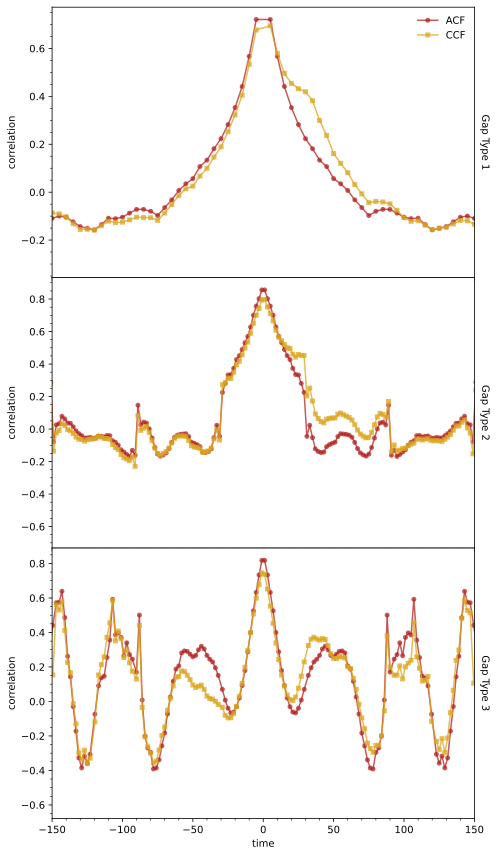

In [11]:
acf_44_gap_1 = photRM.add_inverted_acf(acf_44_gap_1)
acf_44_gap_2 = photRM.add_inverted_acf(acf_44_gap_2)
acf_44_gap_3 = photRM.add_inverted_acf(acf_44_gap_3)

acf_44_gap_1 = acf_44_gap_1.drop_duplicates(subset=['tau']).sort_values('tau')
acf_44_gap_2 = acf_44_gap_2.drop_duplicates(subset=['tau']).sort_values('tau')
acf_44_gap_3 = acf_44_gap_3.drop_duplicates(subset=['tau']).sort_values('tau')

acf_44_gap_1 = photRM.interp(ccf_44_gap_1, acf_44_gap_1)
acf_44_gap_2 = photRM.interp(ccf_44_gap_2, acf_44_gap_2)
acf_44_gap_3 = photRM.interp(ccf_44_gap_3, acf_44_gap_3)

fig, axs = plt.subplots(3, 1, figsize=[7, 12], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_44_gap_1['tau'], acf_44_gap_1['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_44_gap_1['tau'], ccf_44_gap_1['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('Gap Type 1', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-150, 150)
axs[0].legend()

axs[1].plot(acf_44_gap_2['tau'], acf_44_gap_2['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75)
axs[1].plot(ccf_44_gap_2['tau'], ccf_44_gap_2['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75)
axs[1].annotate('Gap Type 2', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[1].set_ylabel('correlation')
axs[1].set_xlim(-150, 150)

axs[2].plot(acf_44_gap_3['tau'], acf_44_gap_3['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75)
axs[2].plot(ccf_44_gap_3['tau'], ccf_44_gap_3['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75)
axs[2].annotate('Gap Type 3', xy=(1.025, 0.5), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[2].set_ylabel('correlation')
axs[2].set_xlim(-150, 150)
axs[2].set_xlabel('time')

plt.show()
plt.close()

Peak candidates (x-axis vals):  [35.]
Max. peak:  35.0
Peak candidates (x-axis vals):  [31. 69. 95.]
Max. peak:  31.0
Peak candidates (x-axis vals):  [32.  72.  76.  90.1]
Max. peak:  32.0


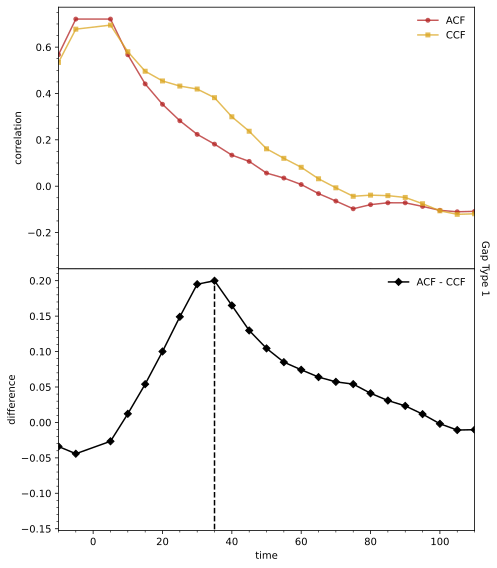

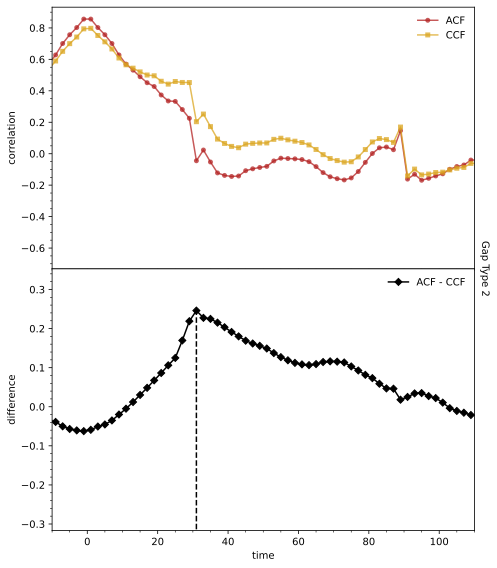

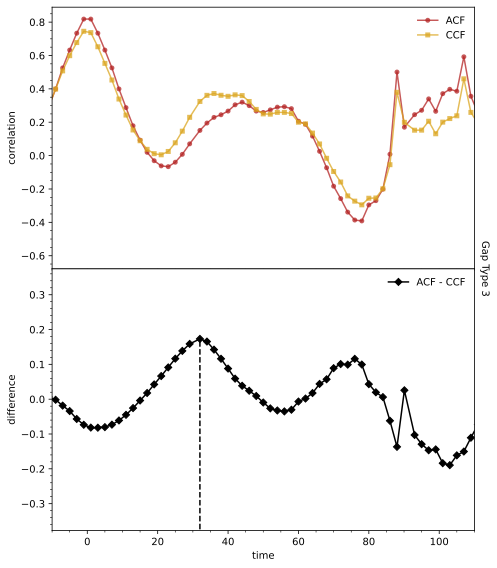

In [12]:
diff_44_gap_1 = photRM.delta_ccf(acf_44_gap_1, ccf_44_gap_1)
diff_44_gap_2 = photRM.delta_ccf(acf_44_gap_2, ccf_44_gap_2)
diff_44_gap_3 = photRM.delta_ccf(acf_44_gap_3, ccf_44_gap_3)

tau_44_gap_1, peaks_x_44_gap_1, peaks_y_44_gap_1 = photRM.peak_finder(diff_44_gap_1.dcf.values,
                                                                      diff_44_gap_1.tau.values,
                                                                      (0,100))
tau_44_gap_2, peaks_x_44_gap_2, peaks_y_44_gap_2 = photRM.peak_finder(diff_44_gap_2.dcf.values,
                                                                      diff_44_gap_2.tau.values,
                                                                      (0,100))
tau_44_gap_3, peaks_x_44_gap_3, peaks_y_44_gap_3 = photRM.peak_finder(diff_44_gap_3.dcf.values,
                                                                      diff_44_gap_3.tau.values,
                                                                      (0,100))

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_44_gap_1['tau'], acf_44_gap_1['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_44_gap_1['tau'], ccf_44_gap_1['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('Gap Type 1', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-10, 110)
axs[0].legend()

axs[1].plot(diff_44_gap_1['tau'], diff_44_gap_1['dcf'], 'D-k', ms=5, label='ACF - CCF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_44_gap_1[0], -100, peaks_y_44_gap_1[0], ls='--', color='k')
axs[1].set_xlim(-10, 110)
axs[1].legend()

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_44_gap_2['tau'], acf_44_gap_2['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_44_gap_2['tau'], ccf_44_gap_2['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('Gap Type 2', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-10, 110)
axs[0].legend()

axs[1].plot(diff_44_gap_2['tau'], diff_44_gap_2['dcf'], 'D-k', ms=5, label='ACF - CCF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_44_gap_2[0], -100, peaks_y_44_gap_2[0], ls='--', color='k')
axs[1].set_xlim(-10, 110)
axs[1].legend()

fig, axs = plt.subplots(2, 1, figsize=[7, 8], sharex=True, layout='tight', gridspec_kw={'hspace': 0})

axs[0].plot(acf_44_gap_3['tau'], acf_44_gap_3['dcf'], 'o-', c='firebrick', mec='none', ms=5, alpha=0.75, label='ACF')
axs[0].plot(ccf_44_gap_3['tau'], ccf_44_gap_3['dcf'], 's-', c='goldenrod', mec='none', ms=5, alpha=0.75, label='CCF')
axs[0].annotate('Gap Type 3', xy=(1.025, 0), xycoords='axes fraction', rotation=270, ha='center', va='center')
axs[0].set_ylabel('correlation')
axs[0].set_xlim(-10, 110)
axs[0].legend()

axs[1].plot(diff_44_gap_3['tau'], diff_44_gap_3['dcf'], 'D-k', ms=5, label='ACF - CCF')
axs[1].set_ylabel('difference')
axs[1].set_xlabel('time')
axs[1].set_ylim(axs[1].set_ylim())
axs[1].vlines(peaks_x_44_gap_3[0], -100, peaks_y_44_gap_3[0], ls='--', color='k')
axs[1].set_xlim(-10, 110)
axs[1].legend()

plt.show()
plt.close()

#### Conclusion:

- regular gap cadence produces more reliable results than noisy alternatives

## 2. Real Observations